# Gradients & Partial Derivatives


---

## 1. Partial Derivatives

> *Nudge one variable — freeze everything else — measure the change.*

$$\frac{\partial f}{\partial x} \rightarrow \text{rate of change w.r.t. } x \text{, with } y \text{ frozen}$$

| Function | ∂f/∂x | ∂f/∂y |
|---|---|---|
| x² + 2y² | 2x | 4y |
| x²y + y³ | 2xy | x² + 3y² |
| x²z + y²z − xyz | 2xz − yz | 2yz − xz |

---

## 2. The Gradient

Bundle all partial derivatives into one vector:

$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n}\right]$$

> - $\nabla f$ → steepest **ascent**
> - $-\nabla f$ → steepest **descent**
> - $|\nabla f|$ → how steep the slope is

**Example — f(x,y) = x² + 2y²**
$$\nabla f = (2x, \ 4y) \quad \text{at } (1,1): \nabla f = (2, 4)$$

---

## 3. Jacobian

For multiple outputs $f: \mathbb{R}^n \rightarrow \mathbb{R}^m$ → an $m \times n$ matrix of all partials.

$$J = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{bmatrix}$$

> Gradient = Jacobian when m=1 (scalar output).  
> In deep learning, backprop multiplies Jacobians at every layer.

---

## 4. Gradient of MSE Loss

$$L = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 \qquad \hat{y}_i = wx_i + b$$

$$\frac{\partial L}{\partial w} = -\frac{2}{n}\sum(y_i - \hat{y}_i)x_i \qquad \frac{\partial L}{\partial b} = -\frac{2}{n}\sum(y_i - \hat{y}_i)$$

---

## 5. Gradient Descent

$$\theta \leftarrow \theta - \alpha \cdot \nabla L(\theta)$$

| α too small | α just right | α too large |
|---|---|---|
| Slow convergence | Smooth | Overshoots / diverges |

> **Critical rule:** Recompute the gradient at the **new point** after every step — never reuse the old gradient.

---

## 6. Python from Scratch

```python
import numpy as np

def f(x, y):        return x**2 + y**2
def grad(x, y):     return (2*x, 2*y)

x, y, alpha = 4.0, 4.0, 0.1

for i in range(20):
    g = grad(x, y)
    x -= alpha * g[0]
    y -= alpha * g[1]
    print(f"Step {i+1:>2} | x: {x:.4f} | y: {y:.4f} | f: {f(x,y):.6f}")
```

**Math behind the output:** every step, x shrinks by factor $(1-2\alpha) = 0.8$

$$x_k = 4 \times 0.8^{20} \approx 0.037 \checkmark$$

---

## 7. Cheatsheet

| Concept | Formula |
|---|---|
| Partial derivative | freeze all others, differentiate one |
| Gradient | $\nabla f = [\partial f/\partial x_1, \dots, \partial f/\partial x_n]$ |
| Update rule | $\theta \leftarrow \theta - \alpha \cdot \nabla L$ |
| MSE grad w.r.t w | $-\frac{2}{n}\sum(y_i - \hat{y}_i)x_i$ |
| Chain rule | $[f(g(x))]' = f'(g(x)) \cdot g'(x)$ |
| Critical point | $\nabla f = 0$ |

In [1]:
import numpy as np

In [2]:
# Problem 1 - Basic Gradient Function
# Define a function called compute_gradient(x, y)
# It should return the gradient of f(x,y) = x² + 3y² as a tuple (df/dx, df/dy)
# Test it at these 3 points and print each result:
# Point 1: (2, 1)
# Point 2: (0, 5)
# Point 3: (3, 3)
def compute_gradient(x,y):
    dfdx = 2*x
    dfdy = 6*y
    return(dfdx,dfdy)
points = [(2,1),(0,5),(3,3)]
for x,y in points:
    print(compute_gradient(x,y))

(4, 6)
(0, 30)
(6, 18)


In [3]:
# Problem 2 - Gradient Descent Loop
# Minimize f(x,y) = x² + y² using gradient descent
# Setup:
#   - Starting point: (4, 4)
#   - Learning rate α = 0.1
#   - Number of steps: 20
# At every step print:
#   Step | x | y | f(x,y)
# Expected: x and y should approach (0,0)
# and f(x,y) should decrease every step
def f(x,y):
    return(x**2 + y **2)
def grad(x,y):
    return(2*x,2*y)
x = 4
y = 4
a = 0.1
step = 20
for i in range(step + 1):
    g = grad(x,y)
    x -= a*g[0]
    y -= a*g[1]
    print(f"step{i},{x},{y},f(x,y) = {f(x,y)}")

step0,3.2,3.2,f(x,y) = 20.480000000000004
step1,2.56,2.56,f(x,y) = 13.1072
step2,2.048,2.048,f(x,y) = 8.388608
step3,1.6384,1.6384,f(x,y) = 5.36870912
step4,1.31072,1.31072,f(x,y) = 3.4359738368000006
step5,1.0485760000000002,1.0485760000000002,f(x,y) = 2.199023255552001
step6,0.8388608000000002,0.8388608000000002,f(x,y) = 1.4073748835532807
step7,0.6710886400000001,0.6710886400000001,f(x,y) = 0.9007199254740995
step8,0.5368709120000001,0.5368709120000001,f(x,y) = 0.5764607523034238
step9,0.4294967296000001,0.4294967296000001,f(x,y) = 0.36893488147419123
step10,0.3435973836800001,0.3435973836800001,f(x,y) = 0.23611832414348238
step11,0.27487790694400005,0.27487790694400005,f(x,y) = 0.1511157274518287
step12,0.21990232555520003,0.21990232555520003,f(x,y) = 0.09671406556917037
step13,0.17592186044416003,0.17592186044416003,f(x,y) = 0.06189700196426903
step14,0.140737488355328,0.140737488355328,f(x,y) = 0.03961408125713217
step15,0.11258999068426241,0.11258999068426241,f(x,y) = 0.02535301

20.480000000000004
13.1072
8.388608
5.36870912
3.4359738368000006
2.199023255552001
1.4073748835532807
0.9007199254740995
0.5764607523034238
0.36893488147419123
0.23611832414348238
0.1511157274518287
0.09671406556917037
0.06189700196426903
0.03961408125713217
0.025353012004564593
0.01622592768292134
0.010384593717069656
0.006646139978924581
0.004253529586511731


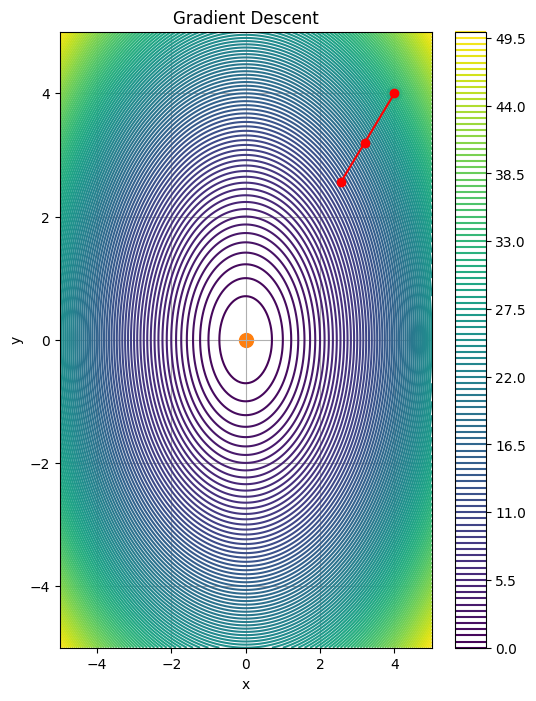

In [4]:
# Problem 3 - Visualize the Descent Path
# Use matplotlib to plot gradient descent on a contour map
# Steps:
#   1. Create a grid using np.meshgrid for x,y in range (-5, 5)
#   2. Compute Z = x² + y² on the grid
#   3. Draw contour rings using plt.contour()
#   4. Run gradient descent from (4,4) with α=0.1 for 20 steps
#      and store every (x,y) in a list called path
#   5. Plot the path as a red line with dots
#   6. Mark start point (4,4) as a blue dot
#   7. Mark minimum (0,0) as a green dot
#   8. Add labels, title, colorbar
# Hint: path = [(x0,y0), (x1,y1), ...]
#       xs = [p[0] for p in path]
#       ys = [p[1] for p in path]
import matplotlib.pyplot as plt
def gradi(x,y):
    return(x*2,y*2)
def f(x,y):
    return(x**2 + y**2)
step = 20
x = 4
y = 4
a =0.1
for  i in range (20):
    g = gradi(x,y)
    x -= a*g[0]
    y -= a*g[1]
    print(f(x,y))
x_val = np.linspace(-5,5,200)
y_val = np.linspace(-5,5,200)
X,Y = np.meshgrid(x_val,y_val)
Z = X**2 + Y**2
plt.figure(figsize=(6,8))
contors = plt.contour(X,Y,Z,levels = 100)
plt.colorbar(contors)
path = [(4,4), (3.2,3.2), (2.56,2.56)]
xs = [p[0] for p in path]
ys = [p[1] for p in path]
xs = [4, 3.2, 2.56]
ys = [4, 3.2, 2.56]
plt.plot(xs, ys, 'r-o')
plt.scatter(4, 4, s=100)
plt.scatter(0, 0, s=100)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent")
plt.grid(True)
plt.show()

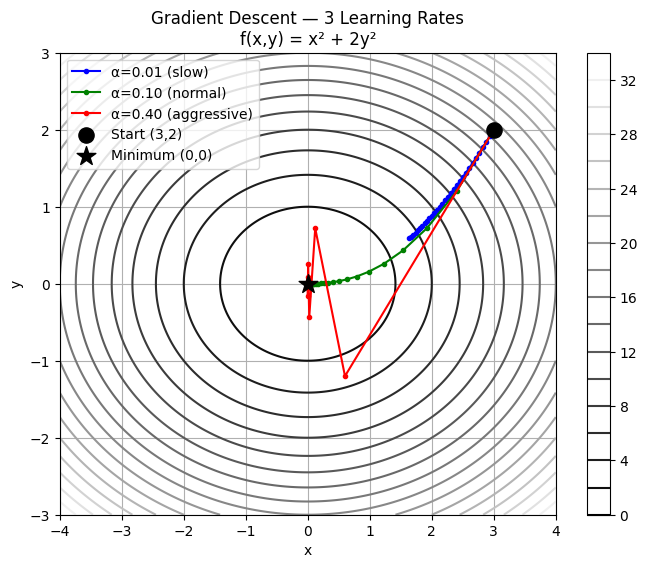

In [5]:
# Problem 4 - Compare 3 Learning Rates
# Minimize f(x,y) = x² + 2y² from starting point (3, 2)
# Run 30 steps for each of these learning rates:
#   α1 = 0.01  (slow)
#   α2 = 0.1   (normal)
#   α3 = 0.4   (aggressive)
# Plot all 3 paths on the SAME contour map
#   - α=0.01 path → blue
#   - α=0.1  path → green
#   - α=0.4  path → red
# Add a legend showing which color = which learning rate
def gradi(x, y):
    return (x*2, 4*y)
def f(x, y):
    return (x**2 + 2*y**2)

alphas = [0.01, 0.1, 0.4]
colors = ['blue', 'green', 'red']
labels = ['α=0.01 (slow)', 'α=0.10 (normal)', 'α=0.40 (aggressive)']
paths  = []
for a in alphas:
    x, y = 3.0, 2.0          
    path = [(x, y)]
    for i in range(30):
        g = gradi(x, y)
        x -= a * g[0]
        y -= a * g[1]
        path.append((x, y))
    paths.append(path)
x_val = np.linspace(-4, 4, 200)
y_val = np.linspace(-3, 3, 200)
X, Y  = np.meshgrid(x_val, y_val)
Z     = X**2 + 2*Y**2        

plt.figure(figsize=(8, 6))
plt.colorbar(plt.contour(X, Y, Z, levels=20, cmap='gray'))

for path, color, label in zip(paths, colors, labels):
    xs, ys = zip(*path)
    plt.plot(xs, ys, '-o', color=color, markersize=3, label=label)
plt.scatter(3, 2, color='black', s=120, zorder=5, label='Start (3,2)')
plt.scatter(0, 0, color='black', s=200, marker='*', zorder=5, label='Minimum (0,0)')
plt.xlabel("x"); plt.ylabel("y")
plt.title("Gradient Descent — 3 Learning Rates\nf(x,y) = x² + 2y²")
plt.legend()
plt.grid(True)
plt.show()